race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


/tmp/ipykernel_2016/885253166.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  count_plot = sns.countplot(x='readmitted_binary', data=df, palette='viridis')
/tmp/ipykernel_2016/885253166.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  count_plot.set_xticklabels(['Not Readmitted (<30d)', 'Readmitted (<30d)'])


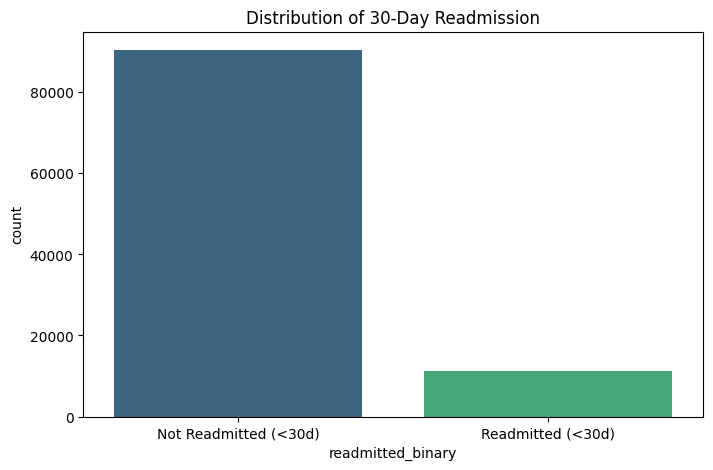

/tmp/ipykernel_2016/885253166.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_xticklabels(['No', 'Yes'])


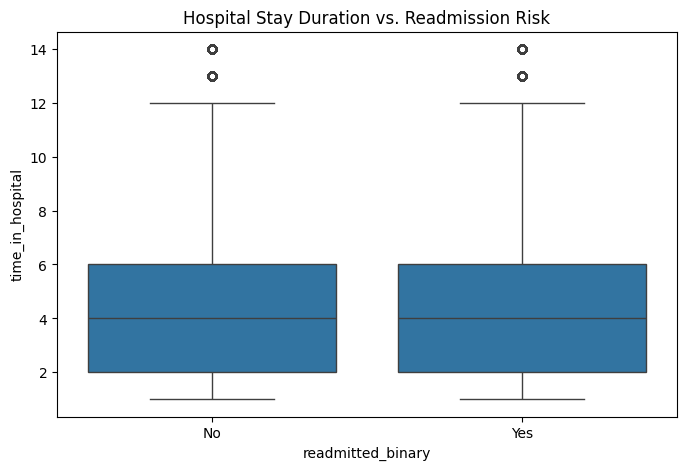

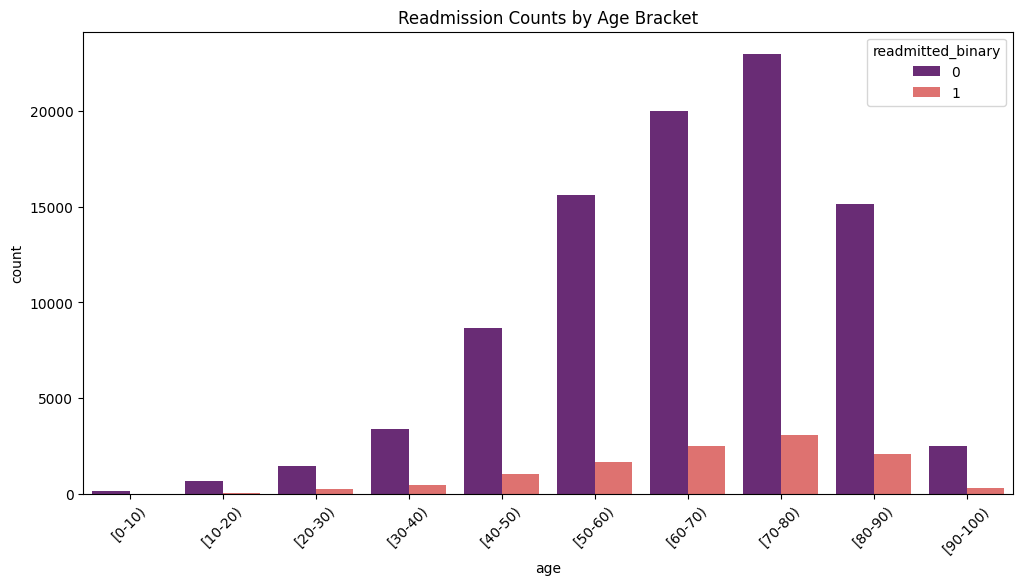

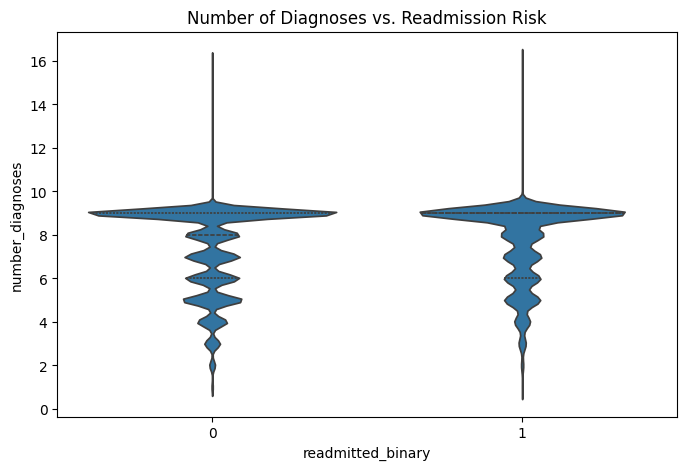

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('sample_data/diabetic_data.csv')
ids_df = pd.read_csv('sample_data/IDS_mapping.csv')
df.head()

#clean '?' to present as nans
df.replace('?', np.nan, inplace=True)
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Weight, Payer Code, and Medical Specialty have massive gaps (Weight is missing in ~98k out of 101k rows). Features like 'weight' and 'payer_code' will be excluded from the final model due to a high volume of missing values, ensuring the model relies on more complete clinical data.
# Diagnoses (diag_1, 2, 3) have very few missing values. Missing values in diagnosis codes are minimal and will be handled by removing those specific rows to maintain data integrity.

#create target variable
target_map = {'NO': 0, '<30': 1, '>30': 0}
df['readmitted_binary'] = df['readmitted'].map(target_map)
#print(df['readmitted_binary'].value_counts())

#count plot - readmitted vs not in the span of 30 days
plt.figure(figsize=(8, 5))
count_plot = sns.countplot(x='readmitted_binary', data=df, palette='viridis')
count_plot.set_xticklabels(['Not Readmitted (<30d)', 'Readmitted (<30d)'])
plt.title('Distribution of 30-Day Readmission')
plt.show()

#boxplot - time in hostpital with readmitted
plt.figure(figsize=(8, 5))
boxplot = sns.boxplot(x='readmitted_binary', y='time_in_hospital', data=df)
boxplot.set_xticklabels(['No', 'Yes'])
plt.title('Hospital Stay Duration vs. Readmission Risk')
plt.show()
#It appears that length of stay alone might not be a strong predictor of readmission.

#Plot showing how readmission rates change with age
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='age', hue='readmitted_binary', palette='magma')
plt.title('Readmission Counts by Age Bracket')
plt.xticks(rotation=45)
plt.show()
#The age distribution is left-skewed. It looks like readmission increases with age and before it drops off again at the far end.

#This plot is also important for our research question on who is most at risk. It compares diagnoses with readmission.
plt.figure(figsize=(8, 5))
sns.violinplot(x='readmitted_binary', y='number_diagnoses', data=df, inner="quart")
plt.title('Number of Diagnoses vs. Readmission Risk')
plt.show()
#The violin plot reveals that patients who are readmitted within 30 days tend to have a higher density of diagnoses (concentrated around 9). This indicates that medical complexity, represented by the number of comorbidities, is likely a stronger predictor of readmission than simple demographic data.

#It appears that number of diagnoses will provide better group separation than stay duration.